In [1]:
import numpy as np

In [2]:
%env JAX_ENABLE_X64=True

env: JAX_ENABLE_X64=True


In [3]:
from lenstronomy.LensModel.lens_model import LensModel
import lensinggw.constants.constants as const
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle

In [4]:
import sys
import os
path = os.getcwd()
dir = '/home/manchun.yeung/microlensing/wolensing/wolensing'
sys.path.append(dir)

In [5]:
from plot.plot import plot_contour
import amplification_factor.amplification_factor as af
from lensmodels.potential import potential

In [7]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')

The macroimage where the microlens is placed around.

In [8]:
type2 = False

In [9]:
ym = 0.8
angle = np.radians(float(0))

Importing constants

In [10]:
G = const.G  # gravitational constant [m^3 kg^-1 s^-2]
c = const.c  # speed of light [m/s]
M_sun = const.M_sun  # Solar mass [Kg]

In [11]:
y0, y1 = 0.5, 0 # source position
l0, l1 = 0., 0 # lens position

zS = 1.0 # source redshift
zL = 0.5 # lens redshift

In [12]:
mL1 = 1e10
mL2 = 20
mtot = mL1 + mL2

# convert to radians
from lensinggw.utils.utils import param_processing
thetaE1 = param_processing(zL, zS, mL1)
thetaE2 = param_processing(zL, zS, mL2)
thetaE = param_processing(zL, zS, mtot)

In [13]:
ts = np.loadtxt('0.6_ts.txt')
Ft = np.loadtxt('0.6_Ft.txt')

In [14]:
plt.plot(ts, Ft)

Error in callback <function _draw_all_if_interactive at 0x7fb945942f80> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 350x262.5 with 1 Axes>

In [12]:
Mpc=3.085677581491367e+22
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=69.7, Om0=0.306, Tcmb0=2.725)
DL       = cosmo.angular_diameter_distance(zL)
DS       = cosmo.angular_diameter_distance(zS)
DLS      = cosmo.angular_diameter_distance_z1z2(zL, zS)
D        = DLS/(DL*DS)
print(np.float64(D/Mpc))

1.097926071881248e-26


In [13]:
from utils.utils import Einstein_radius

In [14]:
Einstein_radius(zL, zS, mtot)

1.097926071881248e-26


8.052888069635299e-07

In [28]:
Einstein_radius(zL, zS, masses[0])

1.097926071881248e-26


6.237740270276241e-11


---- Will perform only the macromodel analysis ----

---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro         --> True
Scaled            --> False
SearchWindowMacro --> 8.052888061582412e-06
PixelsMacro       --> 1000
PrecisionLimit    --> 1e-20
OverlapDistMacro  --> 1e-17
NearSource        --> False
Optimization      --> False
Verbose           --> False




MACROIMAGES

ra: [-4.02644403e-07  1.20793321e-06]
dec: [-4.23516474e-22 -4.23516474e-22]

[1.20792627e-06 1.20792167e-06 1.20788023e-06 1.20800466e-06] [-9.71946114e-11  1.12458487e-10  3.17491009e-11  2.35570657e-11] Img_pos
[1.20792399e-06 1.20791221e-06 1.20788707e-06 1.20800955e-06] [-9.09880264e-11  1.07350428e-10  5.56574479e-11  3.38337647e-11] Img_pos
[1.20792353e-06 1.20790870e-06 1.20788978e-06 1.20801082e-06] [-8.94182082e-11  1.03600177e-10  6.41909924e-11  3.63013954e-11] Img_pos
[1.20792310e-06 1.20790334e-06 1.20789428e-06 1.20801211e-06] [-8.78499200e-11

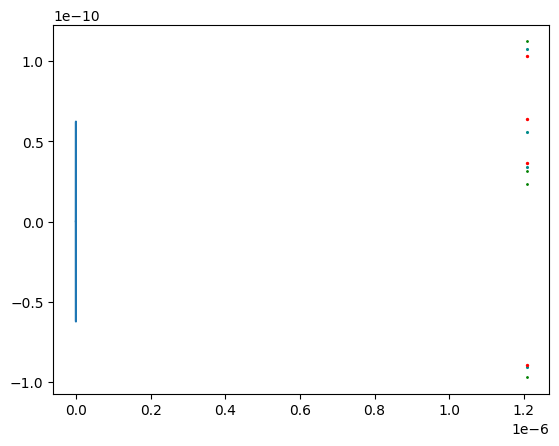

In [33]:
beta0, beta1 = y0 * thetaE, y1 * thetaE
eta10, eta11 = 0 * l0 * thetaE, 0 * l1 * thetaE
lens_model_list = ['SIS']
kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
kwargs_lens_list = [kwargs_sis_1]

kwargs_sis_1_scaled = {'center_x': eta10 / thetaE, 'center_y': eta11 / thetaE, 'theta_E': thetaE1 / thetaE}
kwargs_lens_list_scaled = [kwargs_sis_1_scaled]

from lensinggw.solver.images import microimages
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 5 * thetaE2,
                 'OverlapDistMacro': 1e-17,
                 'OnlyMacro': True}
MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                     source_pos_y=beta1,
                                                     lens_model_list=lens_model_list,
                                                     kwargs_lens=kwargs_lens_list,
                                                     **solver_kwargs)

Td = TimeDelay(MacroImg_ra, MacroImg_dec,
                beta0, beta1,
                zL, zS,
                lens_model_list, kwargs_lens_list)
Mus = magnifications(MacroImg_ra, MacroImg_dec, lens_model_list, kwargs_lens_list)
if type2:
    microtype = np.nonzero(Td)[0][0]
else:
    microtype = np.where(Td==0)[0][0]

masses = [60]
angle = [45]
ym = [0.4, 0.6, 0.65, 0.7]

from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.lens_model import LensModel

num_points = len(ym)

from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions

img_x, img_y = [], []
mus = []
for j in range(len(ym)):
    theta_E = param_processing(zL, zS, masses[0])# lens model
    #positioning the microlenses
    lens_model_list = ['SIS']
    kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
    kwargs_lens_list = [kwargs_sis_1]
    eta20 = MacroImg_ra[microtype] + ym[j]*np.cos(np.radians(45)) * theta_E
    eta21 = MacroImg_dec[microtype] + ym[j] * np.sin(np.radians(45)) * theta_E
    lens_model_list.append('POINT_MASS')
    kwargs_lens_list.append({'center_x': eta20, 'center_y': eta21, 'theta_E': theta_E})

  
    lensmodel = LensModel(lens_model_list=lens_model_list)
    solver = LensEquationSolver(
        lensModel = lensmodel
    )
    Img_ra, Img_dec = solver.image_position_stochastic(
        source_x = beta0,
        source_y = beta1,
        kwargs_lens = kwargs_lens_list,
        # min_distance = 1e-13,
        # solver='lenstronomy'
        search_window = 20*thetaE2,
        # verbose=True,
        precision_limit=10**(-17),
        x_center = MacroImg_ra[microtype],
        y_center= MacroImg_dec[microtype]
    )

    img_x.append(Img_ra)
    img_y.append(Img_dec)
    mus.append(magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list))

    lens_model_complete = LensModel(lens_model_list=lens_model_list)
    T = lens_model_complete.fermat_potential
    T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]

    fig1, ax1 = plt.subplots()
    plot_contour(ax1, lens_model_list, MacroImg_ra[microtype], MacroImg_dec[microtype], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)
    plt.savefig(f'./{ym[j]}_ts.png')
    plt.close()

    lens_model_complete = LensModel(lens_model_list=lens_model_list)
    lensmodelext = LensModelExtensions(lens_model_complete)
    
colorlist = ['green', 'darkcyan', 'red']


lens_model_complete = LensModel(lens_model_list=lens_model_list)
lensmodelext = LensModelExtensions(lens_model_complete)
ra_crit_list, dec_crit_list = lensmodelext.critical_curve_tiling(kwargs_lens_list, compute_window=10*thetaE2, start_scale = thetaE2/100, center_x=MacroImg_ra[1], center_y=MacroImg_dec[1])
ra_caustic_list, dec_caustic_list = lens_model_complete.ray_shooting(ra_crit_list, dec_crit_list, kwargs_lens_list)
macro_srcx, macro_srcy = lens_model_complete.ray_shooting(MacroImg_ra, MacroImg_dec, kwargs_lens_list)
lens_srcx, lens_srcy = lens_model_complete.ray_shooting(eta20, eta21, kwargs_lens_list)

x = ra_crit_list - eta20
y = dec_crit_list - eta21

r = np.sqrt(x**2+y**2)
theta = np.arctan2(y, x) # Angle in radians

sorted_indices = np.argsort(theta)
plt.plot(x[sorted_indices], y[sorted_indices])

mag = np.sqrt(mus[0][1]**2 + mus[0][2]**2)

for i, color in enumerate(colorlist):
    size = 1
    
    temp_mag = np.sqrt(mus[i][1]**2 + mus[i][2]**2)
    if temp_mag> mag:
        size = temp_mag/mag
        
    plt.scatter(img_x[i]-eta20, img_y[i]-eta21, s=size, color=color)
    
plt.savefig('crits.png')

# mass_density = 100
# from utils.lensing import *
# radius = injection_radius(masses, mass_density) #rad
# lens_model_list, kwargs_lens_list = field_injection(zL, zS, MacroImg_ra[microtype], MacroImg_dec[microtype], masses, radius, lens_model_list, kwargs_lens_list, seed=1)
    
# Injecting microlens around desired macroimage
# eta20, eta21 = MacroImg_ra[microtype] + np.cos(angle)*ym*thetaE2, MacroImg_dec[microtype] + np.sin(angle)*ym*thetaE2
# lens_model_list = ['SIS', 'POINT_MASS']
# kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
# kwargs_point_mass_2 = {'center_x': eta20, 'center_y': eta21, 'theta_E': thetaE2}
# kwargs_lens_list = [kwargs_sis_1, kwargs_point_mass_2]

# from lensinggw.solver.images import microimages
# solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
#                  'SearchWindow': 40 * thetaE2,
#                  'Pixels': 5*1e3,
#                  # 'ImgIndex': 1,
#                  'Optimization': True,
#                  'OverlapDist': 1e-18,
#                  'OverlapDistMacro': 1e-17}
# solver_kwargs.update({'Improvement' : 0.1})
# solver_kwargs.update({'MinDist' : 10**(-7)})

# Img_ra, Img_dec, MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
#                                                                       source_pos_y=beta1,
#                                                                       lens_model_list=lens_model_list,
#                                                                       kwargs_lens=kwargs_lens_list,
#                                                                       **solver_kwargs)
# Images_dict = {'Source_ra': beta0,
#                'Source_dec': beta1,
#                'Img_ra': Img_ra,
#                'Img_dec': Img_dec,
#                'MacroImg_ra': MacroImg_ra,
#                'MacroImg_dec': MacroImg_dec,
#                'Microlens_ra': [eta20],
#                'Microlens_dec': [eta21],
#                'thetaE': thetaE}

# # time delays, magnifications, Morse indices 
# from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
# from lensinggw.amplification_factor.amplification_factor import geometricalOpticsMagnification
# tds = TimeDelay(Img_ra, Img_dec,
#                beta0, beta1,
#                zL, zS,
#                lens_model_list, kwargs_lens_list)
# mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
# ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)
# print('Time delays (seconds): ', tds)
# print('magnifications: ', mus)
# print('Morse indices: ', ns)
    
# lens_model_complete = LensModel(lens_model_list=lens_model_list)
# T = lens_model_complete.fermat_potential
# T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]
# if not isinstance(T0, float):
#     T0 = T0[0]
# Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3
# print('T0 = {}'.format(T0))
# print('Tscale = {}'.format(Tscale))

In [23]:
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]


In [36]:
img_y[0]-eta21

array([-1.28069851e-10,  8.15832482e-11,  8.73861742e-13, -7.31817337e-12])

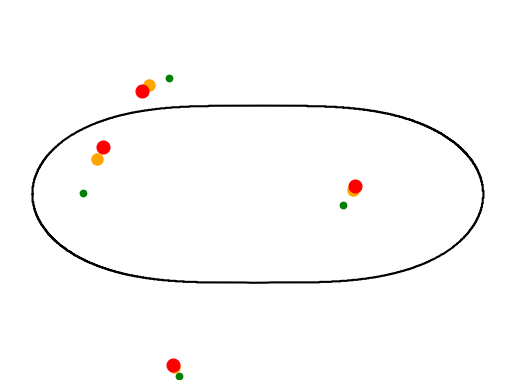

In [42]:
colorlist = ['green', 'orange', 'red']

plt.plot(x[sorted_indices], y[sorted_indices], color='black')

mag = np.sqrt(mus[0][1]**2 + mus[0][2]**2)

for i, color in enumerate(colorlist):
    size = 21
    
    temp_mag = np.sqrt(mus[i][1]**2 + mus[i][2]**2)
    if temp_mag> mag:
        size = 21 * temp_mag/mag * 2
        
    plt.scatter(img_x[i]-eta20, img_y[i]-eta21, s=size, color=color)

plt.ylim(-1.3e-10, 1.3e-10)
plt.axis('off')
plt.savefig('crits.png')

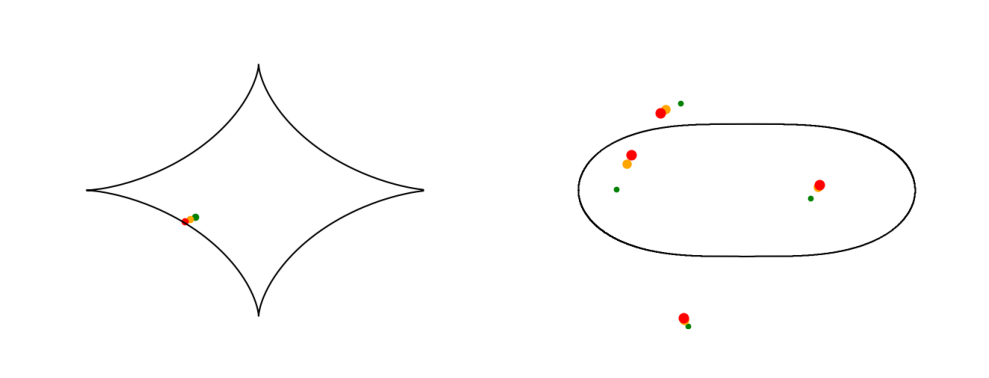

In [49]:
import matplotlib.image as mpimg
img1 = mpimg.imread("caus.png")
img2 = mpimg.imread("crits.png")

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the images
ax[0].imshow(img1)
ax[0].axis("off")  # Turn off axes
# ax[0].set_title("Figure 1")

ax[1].imshow(img2)
ax[1].axis("off")  # Turn off axes
# ax[1].set_title("Figure 2")

# Adjust layout
plt.tight_layout()
# plt.show()
plt.savefig('crit_caus.png')

In [16]:
Img_ra = np.delete(Img_ra, [0])
Img_dec = np.delete(Img_dec, [0])

In [18]:
Img_ra

array([1.20792300e-06, 1.20791858e-06, 1.20782089e-06, 1.20807028e-06])

In [17]:
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.lens_model import LensModel
lensmodel = LensModel(lens_model_list=lens_model_list)
solver = LensEquationSolver(
    lensModel = lensmodel
)
Img_ra, Img_dec = solver.image_position_stochastic(
    source_x = beta0,
    source_y = beta1,
    kwargs_lens = kwargs_lens_list,
    # min_distance = 1e-13,
    # solver='lenstronomy'
    search_window = 20*thetaE2,
    # verbose=True,
    precision_limit=10**(-17),
    x_center = MacroImg_ra[microtype],
    y_center= MacroImg_dec[microtype]
)

In [18]:
Img_ra, Img_dec

(array([1.20792310e-06, 1.20790334e-06, 1.20789428e-06, 1.20801211e-06]),
 array([-8.78499200e-11,  9.58707571e-11,  7.67386794e-11,  3.87355213e-11]))

In [19]:
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]

[-4.02644403e-07  1.20793321e-06] [-4.23516474e-22 -4.23516474e-22] Img_pos


<Axes: >

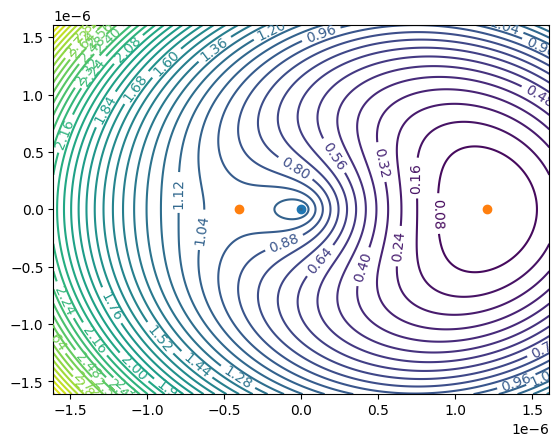

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_contour(ax, lens_model_list, eta10, eta11, 4*thetaE1, kwargs_lens_list, beta0, beta1, MacroImg_ra, MacroImg_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=False)


[1.20792300e-06 1.20791858e-06 1.20782089e-06 1.20807028e-06] [-2.01875088e-10  2.24529048e-10  4.02069557e-11  3.40192125e-11] Img_pos


<Axes: >

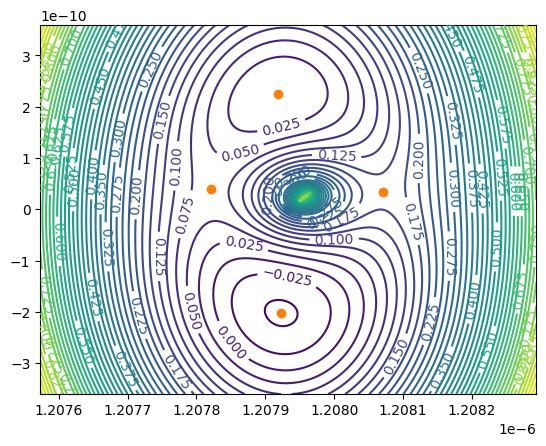

In [25]:
fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[microtype], MacroImg_dec[microtype], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)

In [50]:
masses = [60]
angle = [45]
ym = [0.6]

from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.lens_model import LensModel

num_points = len(ym)

from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions

for j in range(len(ym)):
    theta_E = param_processing(zL, zS, masses[0])# lens model
    #positioning the microlenses
    lens_model_list = ['SIS']
    kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
    kwargs_lens_list = [kwargs_sis_1]
    eta20 = MacroImg_ra[microtype] + ym[j]*np.cos(np.radians(45)) * theta_E
    eta21 = MacroImg_dec[microtype] + ym[j] * np.sin(np.radians(45)) * theta_E
    lens_model_list.append('POINT_MASS')
    kwargs_lens_list.append({'center_x': eta20, 'center_y': eta21, 'theta_E': theta_E})

  
    lensmodel = LensModel(lens_model_list=lens_model_list)
    solver = LensEquationSolver(
        lensModel = lensmodel
    )
    Img_ra, Img_dec = solver.image_position_stochastic(
        source_x = beta0,
        source_y = beta1,
        kwargs_lens = kwargs_lens_list,
        # min_distance = 1e-13,
        # solver='lenstronomy'
        search_window = 20*thetaE2,
        # verbose=True,
        precision_limit=10**(-17),
        x_center = MacroImg_ra[microtype],
        y_center= MacroImg_dec[microtype]
    )


In [22]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# lens_model_list = ['POINT_MASS']
lens_model_complete = LensModel(lens_model_list=lens_model_list)
lensmodelext = LensModelExtensions(lens_model_complete)
ra_crit_list, dec_crit_list = lensmodelext.critical_curve_tiling(kwargs_lens_list, compute_window=10*thetaE2, start_scale = thetaE2/100, center_x=MacroImg_ra[1], center_y=MacroImg_dec[1])
ra_caustic_list, dec_caustic_list = lens_model_complete.ray_shooting(ra_crit_list, dec_crit_list, kwargs_lens_list)
macro_srcx, macro_srcy = lens_model_complete.ray_shooting(MacroImg_ra, MacroImg_dec, kwargs_lens_list)
lens_srcx, lens_srcy = lens_model_complete.ray_shooting(eta20, eta21, kwargs_lens_list)

[1.20792310e-06 1.20790334e-06 1.20789428e-06 1.20801211e-06] [-8.78499200e-11  9.58707571e-11  7.67386794e-11  3.87355213e-11] Img_pos


<Axes: >

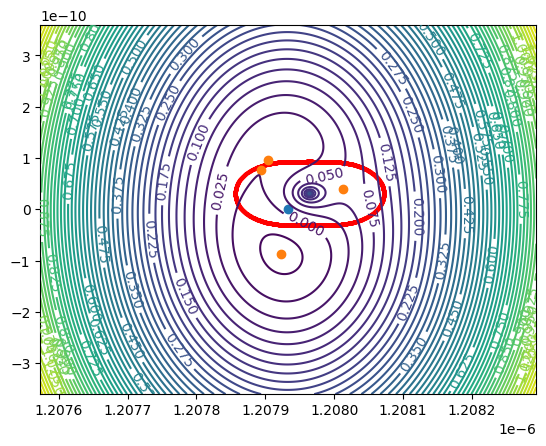

In [23]:
fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[microtype], MacroImg_dec[microtype], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec, crit_ra = ra_crit_list, crit_dec = dec_crit_list,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)

In [58]:
eta20, eta21

(1.2079640848791163e-06, 3.087523911032564e-11)

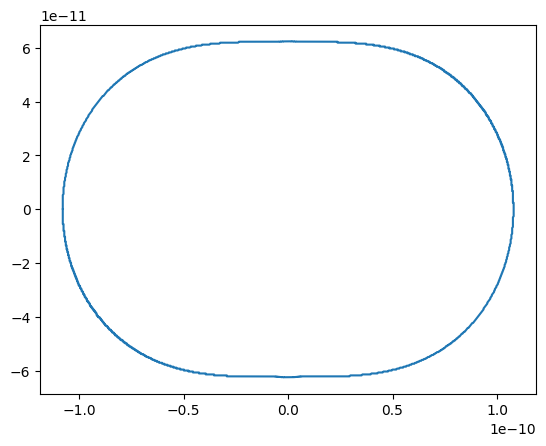

In [59]:
from scipy.spatial import ConvexHull
x = ra_crit_list - eta20
y = dec_crit_list - eta21
# points = np.array([ra_caustic_list, dec_caustic_list])

r = np.sqrt(x**2+y**2)
theta = np.arctan2(y, x) # Angle in radians

# Sort points by theta
sorted_indices = np.argsort(theta)


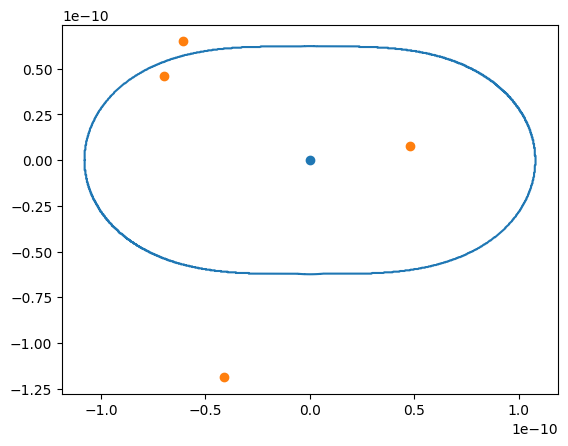

In [60]:
plt.plot(x[sorted_indices], y[sorted_indices])
plt.scatter(0,0)
plt.scatter(Img_ra - eta20, Img_dec - eta21)

In [23]:
micro_srcx, micro_srcy = lens_model_complete.ray_shooting(Img_ra, Img_dec, kwargs_lens_list)


In [24]:
Img_ra, Img_dec

(array([1.20792310e-06, 1.20790334e-06, 1.20789428e-06, 1.20801211e-06]),
 array([-8.78499200e-11,  9.58707571e-11,  7.67386794e-11,  3.87355213e-11]))

In [25]:
micro_srcx, micro_srcy

(array([4.02644403e-07, 4.02644403e-07, 4.02644403e-07, 4.02644403e-07]),
 array([ 1.02803041e-22,  3.63183988e-24, -5.88978446e-23, -2.56813731e-23]))

In [26]:
micro_srcx[1:3]

array([4.02644403e-07, 4.02644403e-07])

In [27]:
mL=60

In [28]:
source1 = np.array([micro_srcx[1], micro_srcy[1]])
source2 = np.array([micro_srcx[2], micro_srcy[2]])

In [44]:
from lensmodels.trip_d import analytic_fold
fs = np.linspace(10, 2000, 1991)
zL = 0.5
img_1 = analytic_fold(lens_model_list, MacroImg_ra[1], Img_dec[1], source1, kwargs_lens_list, zL, zS, mL, fs)
img_2 = analytic_fold(lens_model_list, Img_ra[2], Img_dec[2], source2, kwargs_lens_list, zL, zS, mL, fs)

6984094863.093638 yyy
0.9667717747178707 xx
0.0018538641553377275 1 / Mpc
6.007964560061778e-26
13154314671.047354 yyy
1.2214136669046902 xx
0.0018538641553377275 1 / Mpc
6.007964560061778e-26


In [153]:
source1 = np.array([macro_srcx[0], macro_srcy[0]])
img_1 = analytic_fold(lens_model_list, MacroImg_ra[1], MacroImg_dec[1], source1, kwargs_lens_list, zL, zS, mL, fs)


-66098802318.91406 yyy
0.9999999999973713 xx
0.0018538641553377275 1 / Mpc
6.007964560061778e-26


In [154]:
img_1

array([-0.00104279+0.00104279j, -0.00105949+0.00105949j,
       -0.00107496+0.00107496j, ..., -0.00252133+0.00252133j,
       -0.00252154+0.00252154j, -0.00252175+0.00252175j])

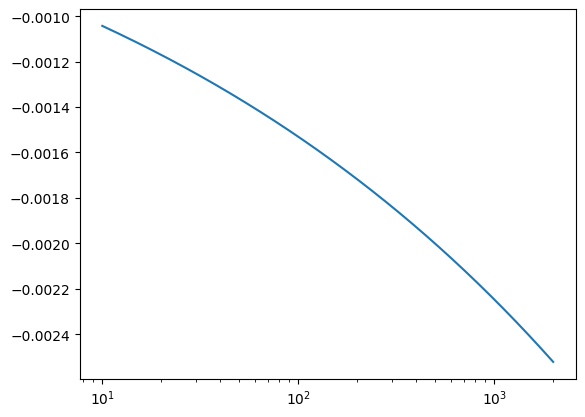

In [156]:
plt.semilogx(fs, img_1)
plt.savefig('analytic_fold.png')

In [32]:
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)

In [34]:
nmus = [mus[0], mus[-1]]
ntds = [tds[0], tds[-1]]
nns = [ns[0], ns[-1]]

In [40]:
from wolensing.utils.utils import compute_geometrical
new_geo = compute_geometrical(fs, nmus, ntds, nns) + img_1 + img_2

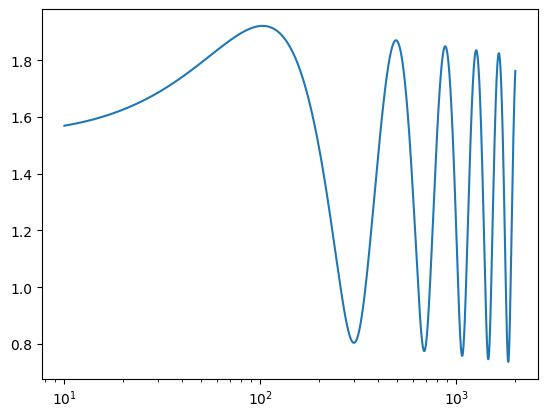

In [41]:
plt.semilogx(fs, np.abs(new_geo))

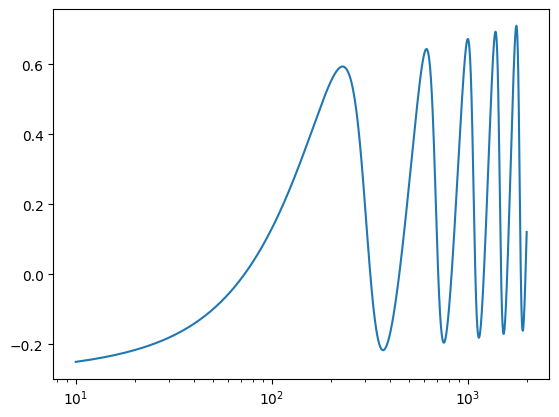

In [43]:
plt.semilogx(fs, np.angle(new_geo))

In [ ]:
from utils.lensing import *
from utils.constants import c
frequencies = [10, 100, 500, 1000, 2000]
radii = [c / freq for freq in frequencies]
print(radii)
radii = [3.24e-17 * r  for r in radii]
# print(radii)
angles = distance_to_angle(radii, zL)

In [ ]:
angles

In [ ]:
thetaE

In [ ]:
# theta = np.linspace(0, 2*np.pi, 100)
# circles_x = [macro_srcx+angles[0]*np.cos(the) for the in theta]
# circles_y = [macro_srcy+angles[0]*np.sin(the) for the in theta]

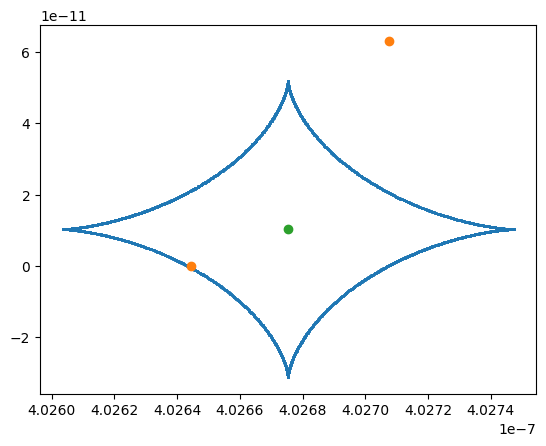

In [24]:
plt.scatter(ra_caustic_list, dec_caustic_list, s=1)
plt.scatter(macro_srcx, macro_srcy)
plt.scatter(lens_srcx, lens_srcy)
# plt.scatter(circles_x, circles_y, s=0.5)

In [56]:
from scipy.spatial import ConvexHull
x = ra_caustic_list - lens_srcx
y = dec_caustic_list - lens_srcy
points = np.array([ra_caustic_list, dec_caustic_list])

r = np.sqrt(x**2+y**2)
theta = np.arctan2(y, x) # Angle in radians

# Sort points by theta
sorted_the = np.sort(theta)
# print(sorted_indices)
# sorted_y = y[sorted_indices]
# sorted_x = x[sorted_indices]

# # Close the curve by appending the first point at the end
# sorted_points = np.vstack([sorted_points, sorted_points[0]])
# plt.plot(sorted_points[:, 0], sorted_points[:, 1], color='red', label='Ordered Curve')

In [52]:
sorted_the[:]

array([-3.14158651, -3.14158598, -3.14158581, ...,  3.14159104,
        3.14159146,  3.14159162])

In [55]:
sorted_indices = np.argsort(theta)

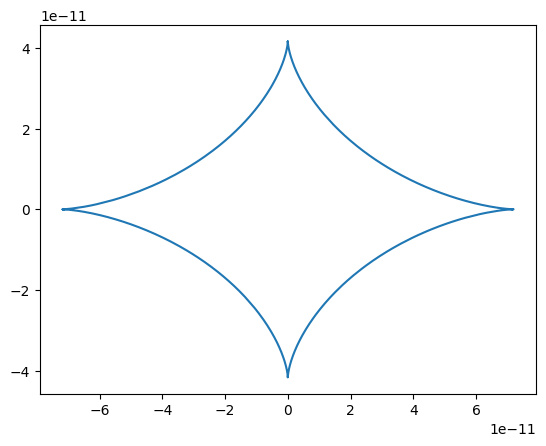

In [57]:
plt.plot(x[sorted_indices], y[sorted_indices])

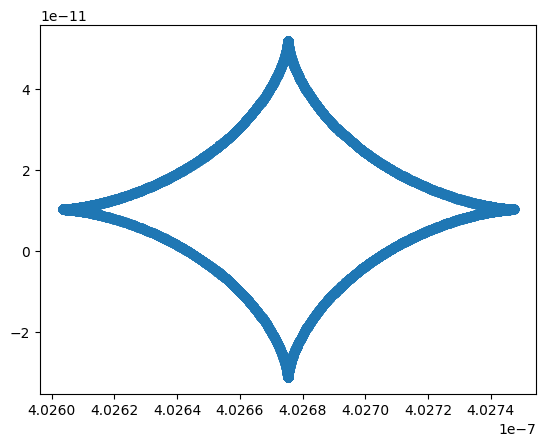

In [42]:
plt.scatter(sorted_x, sorted_y,label='Ordered Curve')

In [105]:
from lensmodels.trip_d import total_triple_d
triple_d =  total_triple_d(lens_model_list, macro_srcx[0], macro_srcy[0], kwargs_lens_list)

In [106]:
from lensmodels.hessian import Hessian_Td
f_xx, f_yy, f_xy = Hessian_Td(lens_model_list, macro_srcx[0], macro_srcy[0], kwargs_lens_list)

In [107]:
f_yyx

-878284.4883079232

In [108]:
tangent = f_xx * np.array([-f_yyy, f_yyx])
tangent_unit = tangent / (np.sqrt(tangent[0]**2+tangent[1]**2))

In [109]:
tangent_unit[0]

-0.9486387564880268

In [ ]:
angle*np.

In [123]:
angle = np.arccos(tangent_unit[0])

In [125]:
angle

2.819701276151377

In [126]:
macro = np.array([macro_srcx[0], macro_srcy[0]])
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
new_macro = np.dot(rotation, macro)

In [127]:
new_macro

array([-3.81964089e-07,  1.27381132e-07])

In [128]:
caustic = np.vstack((ra_caustic_list, dec_caustic_list))
rotated_caustic = np.dot(rotation, caustic)
ncau_x = rotated_caustic[0, :]
ncau_y = rotated_caustic[1, :]

In [129]:
lens_pos = np.array([lens_srcx, lens_srcy])
nlens = np.dot(rotation, lens_pos)

In [130]:

ori_x = nlens[0]
ori_y = nlens[1]
ncau_x -= ori_x
ncau_y -= ori_y
nmac_x = new_macro[0]-ori_x
nmac_y = new_macro[1]-ori_y

In [131]:
nmac_x, nmac_y

(3.254348353473442e-11, -3.4030271810320234e-15)

In [132]:
ncau_x -= ori_x
ncau_y -= ori_y

In [133]:
ncau_x += ori_x
ncau_y += ori_y

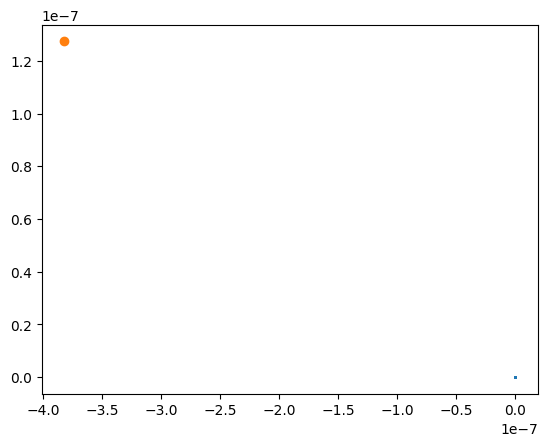

In [135]:
plt.scatter(ncau_x, ncau_y, s=1)
plt.scatter(new_macro[0], new_macro[1])
# plt.scatter(nlens[0], nlens[1])

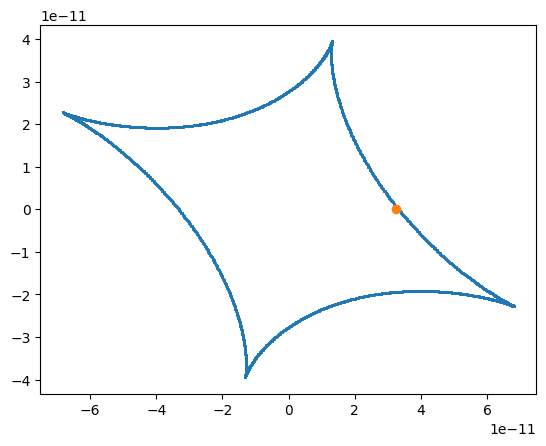

In [136]:
plt.scatter(ncau_x, ncau_y, s=1)
plt.scatter(nmac_x, nmac_y)
# plt.scatter(ori_x, ori_y)

In [137]:
nmac_x, nmac_y

(3.254348353473442e-11, -3.4030271810320234e-15)

In [81]:
new_macro[0], new_macro[1]

(-9.060574695820915e-08, -3.9231762160112505e-07)

In [51]:
Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3


In [52]:
# Define the characteristic WindowSize
mL3 = 10
thetaE3 = param_processing(zL, zS, mL3)

In [53]:
import time

In [54]:
kwargs_macro = {'source_pos_x': beta0,
                'source_pos_y': beta1,
                'theta_E': thetaE,
                'mu': np.abs(Mus[microtype]),
               }

kwargs_integrator = {'PixelNum': int(40000),
                     'PixelBlockMax': 2000,
                     'WindowSize': 2.*210*thetaE3,
                     'WindowCenterX': MacroImg_ra[microtype],
                     'WindowCenterY': MacroImg_dec[microtype],
                     'T0': T0,
                     'TimeStep': 1e-5/Tscale, 
                     'TimeMax': T0 + .7/Tscale,
                     'TimeMin': T0 - .3/Tscale,
                     'TimeLength': 1./Tscale,
                     'TExtend': 10/Tscale,
                     'LastImageT': .02/Tscale,
                     'Tbuffer': .1/Tscale,
                     'Tscale': Tscale}


amplification = af.amplification_factor(lens_model_list=lens_model_list, kwargs_lens=kwargs_lens_list, kwargs_macro=kwargs_macro, **kwargs_integrator)
ts, Ft = amplification.integrator(gpu=False)
ws, Fws = amplification.fourier()
amplification.plot_freq()

start


Integrating...: 100%|██████████| 441/441 [02:26<00:00,  3.01it/s]


[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.43027155e-22
 2.37092688e-22 2.39952672e-22]
29917 1 shi
total time 10.99999


RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x7f39fae66e60> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 0 Axes>

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 1 Axes>

In [55]:
np.savetxt('0.6_ts.txt', ts)
np.savetxt('0.6_Ft.txt', Ft)

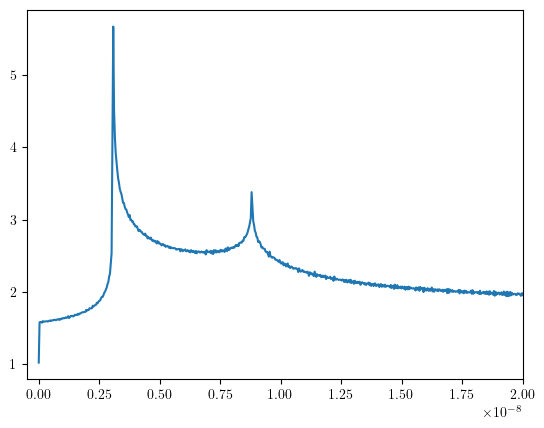

In [82]:
plt.xlim(-.5e-9, 2e-8)
plt.plot(ts, Ft)

<Figure size 640x480 with 0 Axes>

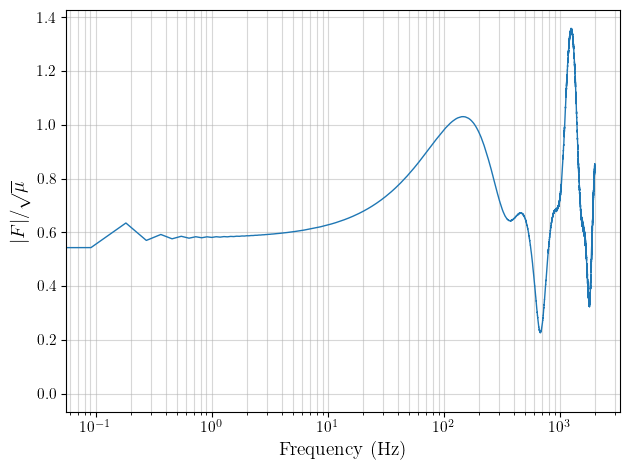

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [80]:
amplification.plot_freq(smooth=False)

<Figure size 640x480 with 0 Axes>

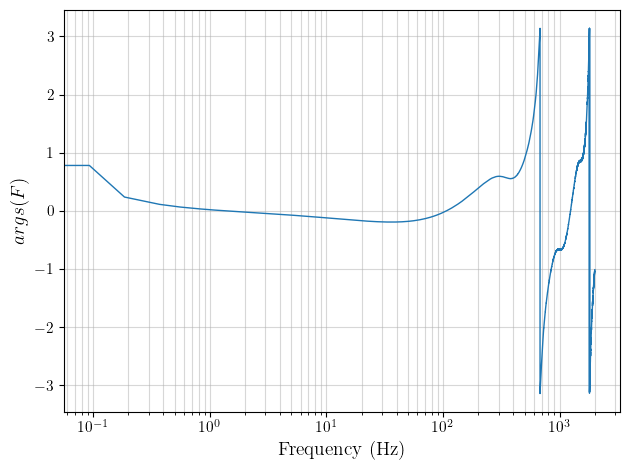

<Axes: xlabel='Frequency (Hz)', ylabel='$args(F)$'>

In [31]:
amplification.plot_freq(pha=True, smooth=False)

# Geometrical optics
To get the geometrical optics around type 1 image, we need the magnifications, time delay and the image positions of the microimages

In [61]:
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)

In [62]:
mus

array([ 2.48805369,  8.78755388, -7.98181437, -0.2937932 ])

In [35]:
tds

array([0.        , 0.00090345, 0.00090653, 0.00260427])

In [76]:
Img_ra, Img_dec

(array([1.20792310e-06, 1.20790334e-06, 1.20789428e-06, 1.20801211e-06]),
 array([-8.78499200e-11,  9.58707571e-11,  7.67386794e-11,  3.87355213e-11]))

In [74]:
from wolensing.utils.utils import Morse_indices
ns = Morse_indices(lens_model_list, Img_ra, Img_dec, kwargs_lens_list)

In [141]:
ntds = np.array([tds[0], tds[-1]])

In [143]:
nmus = np.array([mus[0], mus[-1]])
nns = np.array([ns[0], ns[-1]])

In [145]:
Fmag = 0
for i in range(len(nmus)):
    Fmag += np.sqrt(np.abs(nmus[i]))* np.exp(1j*np.pi*(2.*fs*ntds[i] - nns[i]))

In [148]:
oFmag = 0
for i in range(len(mus)):
    oFmag += np.sqrt(np.abs(mus[i]))* np.exp(1j*np.pi*(2.*fs*tds[i] - ns[i]))

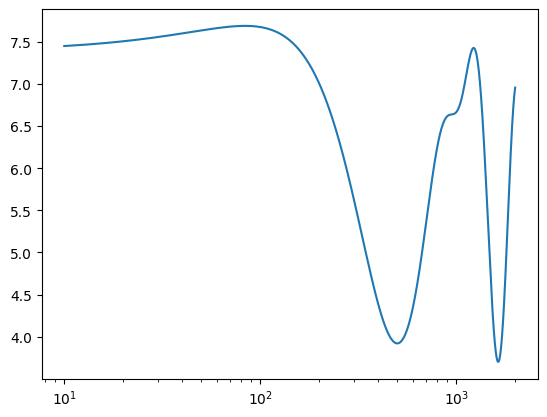

In [157]:
plt.semilogx(fs, np.abs(oFmag-Fmag))
plt.savefig('difference.png')

In [33]:
Img_dec

array([-8.78499200e-11,  9.58707571e-11,  7.67386794e-11,  3.87355213e-11])

In [146]:
geofs, geoFws = amplification.geometrical_optics(mus, tds, Img_ra, Img_dec, upper_lim=2000)

NameError: name 'amplification' is not defined

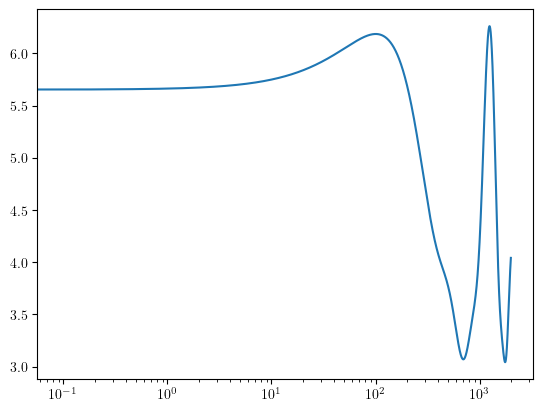

In [35]:
plt.semilogx(geofs, np.abs(geoFws))

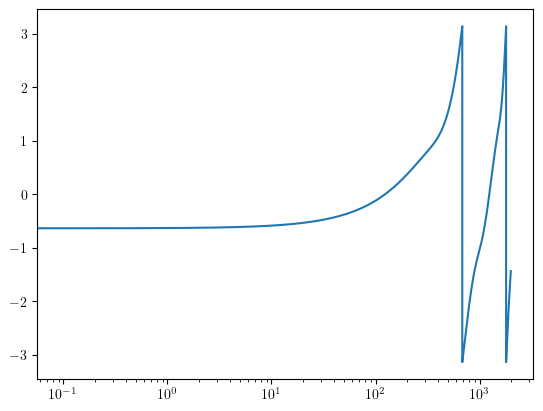

In [36]:
plt.semilogx(geofs, np.angle(geoFws))

# Full amplification factor concatenated with geometrical optics
Given the computaional cost of the diffraction integral, we concatenate the result of wave optics at low frequency and geometrical optics at high frequency to obtain a full amplification factor with default upper bound of 3000Hz.

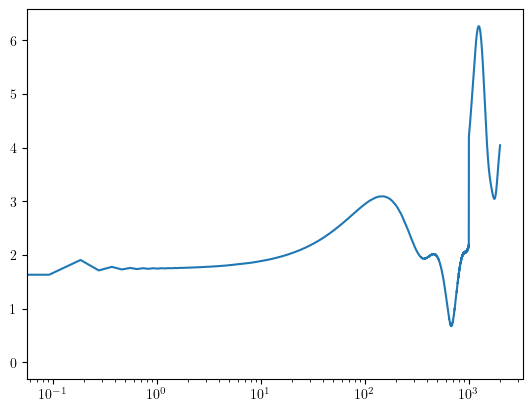

In [37]:
fullfs, fullFws = amplification.concatenate()
plt.semilogx(fullfs, np.abs(fullFws))

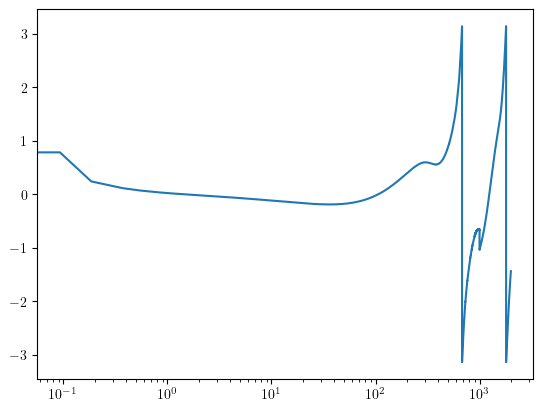

In [38]:
plt.semilogx(fullfs, np.angle(fullFws))

In [39]:
fac = np.sqrt(np.abs(Mus[microtype]))

In [40]:
plt.clf()
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

<Figure size 640x480 with 0 Axes>

In [41]:
from bisect import bisect_left
low_index = bisect_left(geofs, 1)
geofs = geofs[low_index:]
geoFws = geoFws[low_index:]
ws = ws[low_index:]
Fws = Fws[low_index:]

(1, 2000)

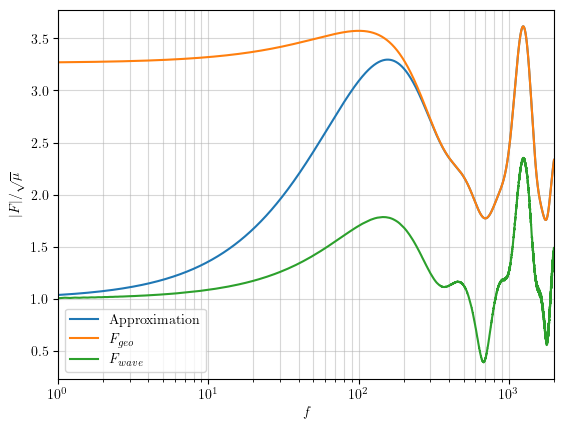

In [42]:
ww = geofs
plt.semilogx(geofs, (fac*np.exp(-ww*np.pi/188) + (1-np.exp(-ww*np.pi/188))*np.abs(geoFws))/fac, label='Approximation')
plt.semilogx(geofs, np.abs(geoFws)/fac,label=r'$F_{geo}$')
plt.semilogx(ws, np.abs(Fws)/fac, label=r'$F_{wave}$')
plt.ylabel(r'$|F|/\sqrt{\mu}$')
plt.xlabel(r'$f$')
plt.grid(which='both', alpha=0.5)
plt.legend()
plt.xlim(1, 2000)
# plt.savefig('./approx.png',bbox_inches='tight', dpi=300)

(1, 2000)

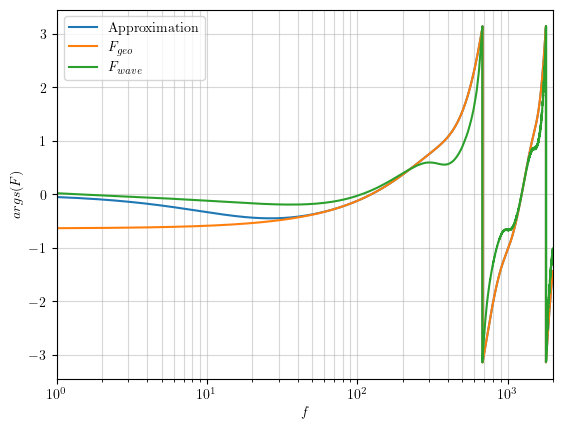

In [43]:
plt.semilogx(geofs, (1-np.exp(-ww*np.pi/37.5))*np.angle(geoFws), label='Approximation')
plt.semilogx(geofs, np.angle(geoFws),label=r'$F_{geo}$')
plt.semilogx(ws, np.angle(Fws), label=r'$F_{wave}$')
plt.ylabel(r'$args(F)$')
plt.xlabel(r'$f$')
plt.grid(which='both', alpha=0.5)
plt.legend()
plt.xlim(1, 2000)
# plt.savefig('./approx_ang.png',bbox_inches='tight', dpi=300)

In [44]:
Abs = (fac*np.exp(-ww*np.pi/1000) + (1-np.exp(-ww*np.pi/1000))*np.abs(geoFws))/fac
Pha = (1-np.exp(-ww*np.pi/1000))*np.angle(geoFws)
complete_approx = Abs * np.exp(1j * Pha)

<Figure size 640x480 with 0 Axes>

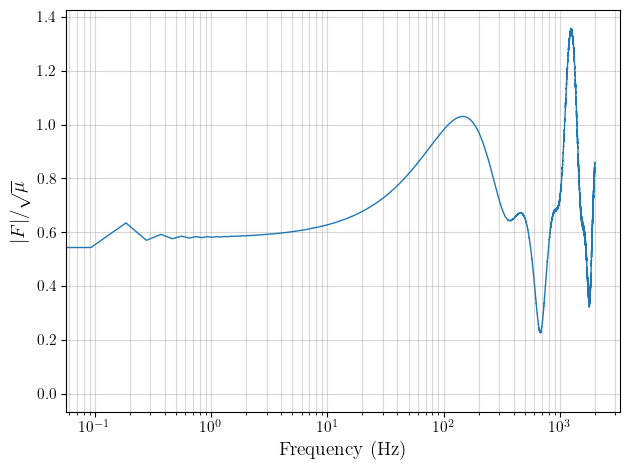

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [45]:
amplification.plot_freq()

<Figure size 640x480 with 0 Axes>

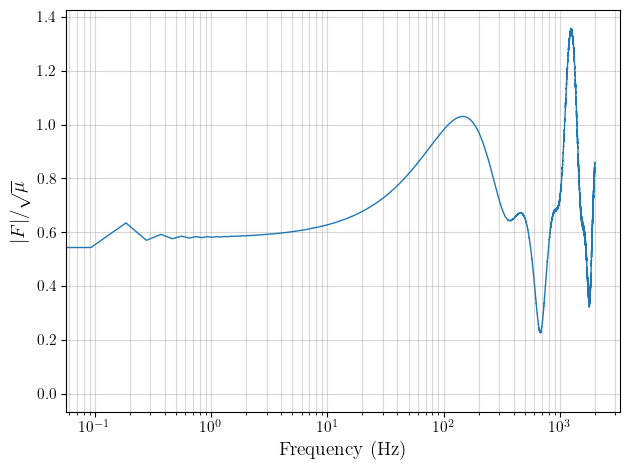

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [46]:
amplification.plot_freq(smooth=False)

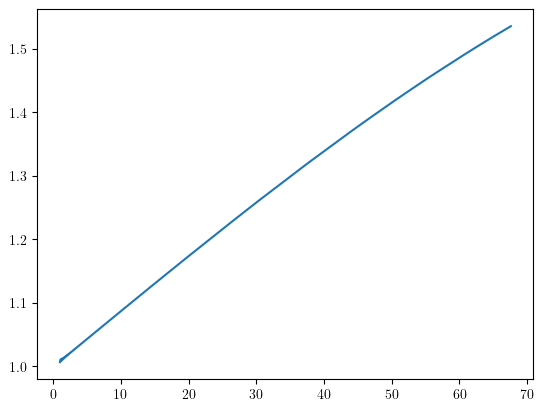

In [47]:
plt.plot(ws[:720], np.abs(Fws[:720])/np.sqrt(3))

In [48]:
from bisect import bisect_left
i = bisect_left(ws, 60)


In [49]:
i

637

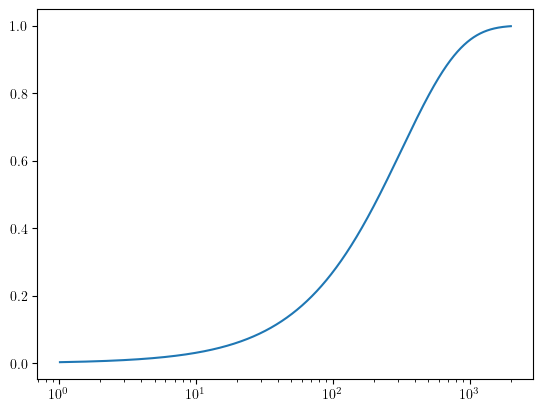

In [50]:
plt.semilogx(ww,(1-np.exp(-ww*np.pi/1000)))

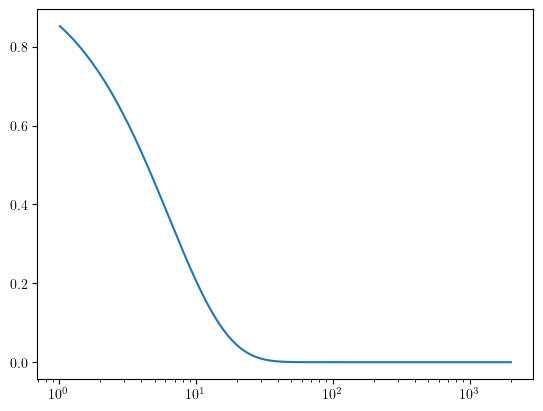

In [51]:
plt.semilogx(ww, np.exp(-ww*np.pi/20))

In [52]:
import pycbc.psd as psd
from pycbc.filter.matchedfilter import overlap, match

hp, hc = get_fd_waveform(approximant = 'IMRPhenomXPHM',
                         mass1 = 30,
                         mass2 = 30,
                         delta_f = .04,
                         f_lower = 10,
                         f_final = 2000)
dfnoise = 0.04
noiselen = int(2001/dfnoise)+1
noise2 = psd.analytical.aLIGOaLIGODesignSensitivityT1800044(noiselen, dfnoise, 1)
noisef = np.linspace(1, 1 + dfnoise*(noiselen-1), num = noiselen)

/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


NameError: name 'get_fd_waveform' is not defined

In [ ]:
np.savetxt('gf.txt', geofs)
np.savetxt('complete.txt', complete_approx)
np.savetxt('ws.txt', ws)
np.savetxt('Fws.txt', Fws)

In [ ]:
np.savetxt('gwoF.txt', geoFws)

In [ ]:
mus, tds, ns

In [ ]:
Img_ra

In [ ]:
from wolensing.utils.utils import *
Morse_indices(amplification._lens_model_list, Img_ra, Img_dec, amplification._kwargs_lens)

In [ ]:
plt.plot(geofs, -0.000435*geofs + np.pi - 23/geofs)